    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm.notebook import tqdm
from IPython.display import clear_output
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [35]:
inds_30 = pd.read_csv('csv/30_industry.csv')
inds_30['Date'] = pd.to_datetime(inds_30['Date'])
inds_30 = inds_30.set_index('Date')
inds_30

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-2.27,-1.16,1.67,-1.57,-2.49,-2.75,-2.40,-0.58,-1.76,-3.74,...,-1.26,2.47,2.24,-2.35,-0.97,-0.62,-2.57,-2.12,-4.11,-2.06
2000-01-04,-2.27,-1.11,0.64,-0.07,-2.72,-2.10,-3.62,-4.39,-1.74,-3.23,...,-4.40,-4.93,-5.68,-2.26,-2.58,-2.96,-3.46,-1.82,-3.90,-1.36
2000-01-05,0.10,1.33,-0.41,-0.40,-2.20,-1.42,1.96,2.32,3.39,1.37,...,0.01,-1.25,-0.90,2.16,0.27,2.16,-0.97,1.19,-0.47,0.21
2000-01-06,1.16,1.29,-1.28,-1.63,0.23,2.69,-0.45,2.68,4.31,-0.26,...,-1.92,-4.03,-5.41,3.17,3.00,3.39,-0.13,-0.73,3.23,0.26
2000-01-07,1.23,5.25,2.75,0.84,-1.23,5.40,1.08,7.61,1.59,1.67,...,0.93,3.46,3.56,1.70,1.10,2.85,4.79,1.50,2.01,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.46,0.21,0.37,0.16,0.28,0.72,1.71,0.58,0.46,0.83,...,0.64,0.19,0.18,0.29,0.30,0.27,0.52,0.63,0.53,0.23
2025-12-26,-0.08,-0.10,-0.21,0.68,-0.71,0.11,0.79,-0.05,0.36,0.37,...,-0.18,-0.15,0.33,0.47,-0.19,0.14,0.19,-0.24,-0.13,-0.56
2025-12-29,0.18,0.19,0.41,-0.44,-0.26,-0.16,0.00,-0.26,-0.37,-0.25,...,0.43,-0.35,-0.44,0.19,-0.30,-0.25,-0.16,-0.59,-0.71,0.44


In [36]:
# ── 고정 파라미터 ──
gamma = 0.0    # regularization 제거
x_min = 0.0
x_max = 1.0   # box constraint 제거

N_STOCKS = len(inds_30.columns)

HORIZON    = 126
REBAL      = 21
N          = HORIZON
M          = N_STOCKS   # 10
C          = 1.0
d          = 1.0
LAM_LIST   = [0.3, 0.5, 0.7]
DELTA_LIST = [20, 50]        # risk aversion [20, 50]
HIDDEN_DIM = 128
EPOCHS     = 300
BATCH_SIZE = 16
LR         = 1e-4
PATIENCE   = 50

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.1, 0.2, 0.3, 0.4]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]



In [37]:
inds_30 = inds_30.sort_index()
inds_30 = inds_30[~inds_30.index.duplicated(keep='first')]
inds_30 = inds_30 / 100.0

stock_names = inds_30.columns.tolist()

# =============================================================================
# 2. Train / Val / Test 분리 (날짜 기준)
# =============================================================================
TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"   # Train : 13년
VAL_START   = "2013-01-01"
VAL_END     = "2017-12-31"   # Val   :  5년
BT_START    = "2018-01-01"
BT_END      = "2025-12-31"   # Test  :  8년

train_df = inds_30[TRAIN_START : TRAIN_END]
is_df    = inds_30[TRAIN_START : VAL_END]
val_df   = inds_30[VAL_START   : VAL_END]
bt_df    = inds_30[BT_START    : BT_END]

train_np = train_df.values
val_np   = val_df.values
bt_np    = bt_df.values

N_TRAIN = len(train_df)
N_VAL   = len(val_df)
N_BT    = len(bt_df)
N_DAYS  = len(inds_30)

print(f"전체  : {inds_30.index[0].date()} → {inds_30.index[-1].date()}  ({N_DAYS} days)")
print(f"Train : {train_df.index[0].date()} → {train_df.index[-1].date()}  ({N_TRAIN} days)")
print(f"Val   : {val_df.index[0].date()} → {val_df.index[-1].date()}  ({N_VAL} days)")
print(f"BT    : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목  : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
# Train 기간 통계로 표준화 (변수명 is_mean/is_std 유지 — .py 파일 호환)
is_mean = train_np.mean(axis=0)   # shape (10,)
is_std  = train_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (lookback, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # Train 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

full_np       = np.vstack([train_np, val_np, bt_np])
VAL_START_IDX = N_TRAIN
BT_START_IDX  = N_TRAIN + N_VAL

for cfg in configs:
    LOOKBACK  = cfg["LOOKBACK"]
    n1        = cfg["n1"]
    INPUT_DIM = LOOKBACK * N_STOCKS

    train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=LOOKBACK, end=N_TRAIN)
    val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
    rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                 start=BT_START_IDX, end=BT_START_IDX + N_BT)
    rebal_samples = rebal_samples[::REBAL]

    print(f"\n[LOOKBACK={LOOKBACK}, n1={n1}]")
    print(f"  Train 학습 샘플 수  : {len(train_samples)}")
    print(f"  Val 전체 샘플 수    : {len(val_samples)}")
    print(f"  BT 리밸런싱 횟수    : {len(rebal_samples)}")

전체  : 2000-01-03 → 2025-12-31  (6539 days)
Train : 2000-01-03 → 2012-12-31  (3269 days)
Val   : 2013-01-02 → 2017-12-29  (1259 days)
BT    : 2018-01-02 → 2025-12-31  (2011 days)
종목  : ['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth', 'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other']

[LOOKBACK=252, n1=0.1]
  Train 학습 샘플 수  : 2892
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    : 90

[LOOKBACK=252, n1=0.2]
  Train 학습 샘플 수  : 2892
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    : 90

[LOOKBACK=252, n1=0.3]
  Train 학습 샘플 수  : 2892
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    : 90

[LOOKBACK=252, n1=0.4]
  Train 학습 샘플 수  : 2892
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    : 90

[LOOKBACK=504, n1=0.1]
  Train 학습 샘플 수  : 2640
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    : 90

[LOOKBACK=504, n1=0.2]
  Train 학습 샘플 수  : 2640
  Val 전체 샘플 수    : 1134
  BT 리밸런싱 횟수    :

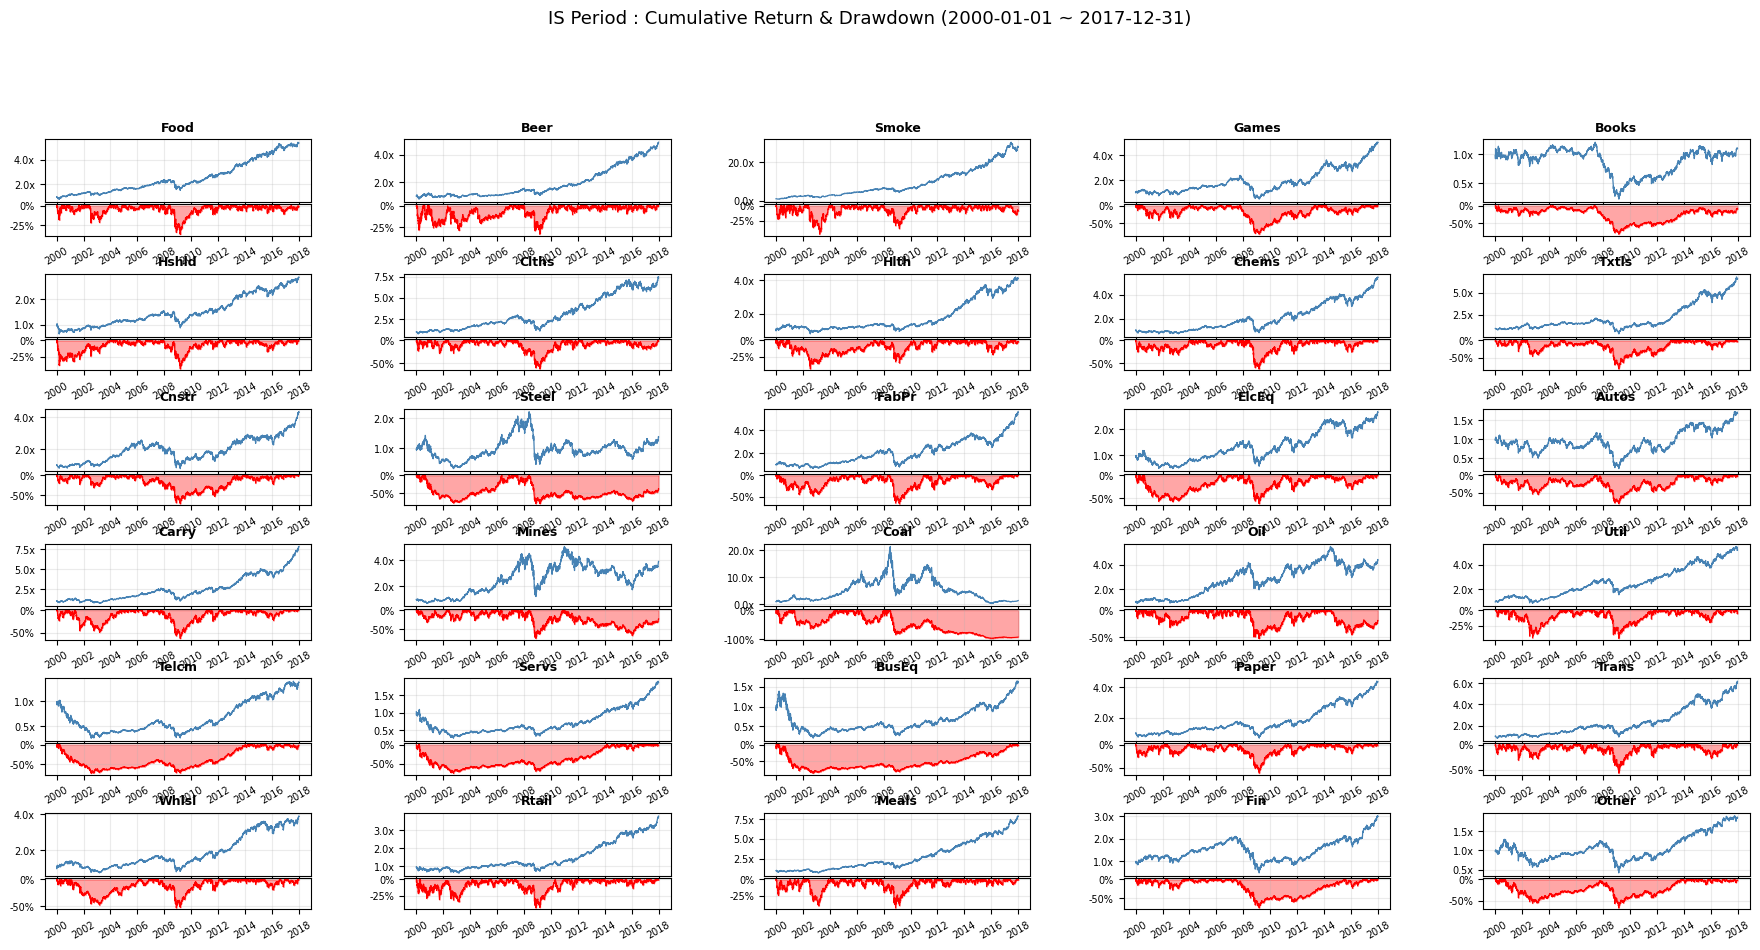

In [38]:
is_cum = (1 + is_df).cumprod()
is_dd  = (is_cum - is_cum.cummax()) / is_cum.cummax()

cols   = is_cum.columns.tolist()  # 10개 종목
N_COLS = 5
N_ROWS = 6  # 종목 행

fig = plt.figure(figsize=(22, 10))
outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

for i, col in enumerate(cols):
    row, c = divmod(i, N_COLS)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[row, c],
        hspace=0.05, height_ratios=[2, 1]
    )

    ax_ret = fig.add_subplot(inner[0])
    ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

    # 상단: 누적 수익률
    ax_ret.plot(is_cum.index, is_cum[col], color="steelblue", linewidth=0.9)
    ax_ret.set_title(col, fontsize=9, fontweight="bold")
    ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
    ax_ret.tick_params(axis="x", labelbottom=False)
    ax_ret.tick_params(labelsize=7)
    ax_ret.grid(True, alpha=0.25)

    # 하단: Drawdown
    ax_dd.fill_between(is_dd.index, is_dd[col], 0, alpha=0.35, color="red")
    ax_dd.plot(is_dd.index, is_dd[col], color="red", linewidth=0.8)
    ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax_dd.tick_params(labelsize=7)
    ax_dd.tick_params(axis="x", rotation=30)
    ax_dd.grid(True, alpha=0.25)

fig.suptitle(f"IS Period : Cumulative Return & Drawdown ({TRAIN_START} ~ {VAL_END})",
             fontsize=13, y=1.01)
plt.show()


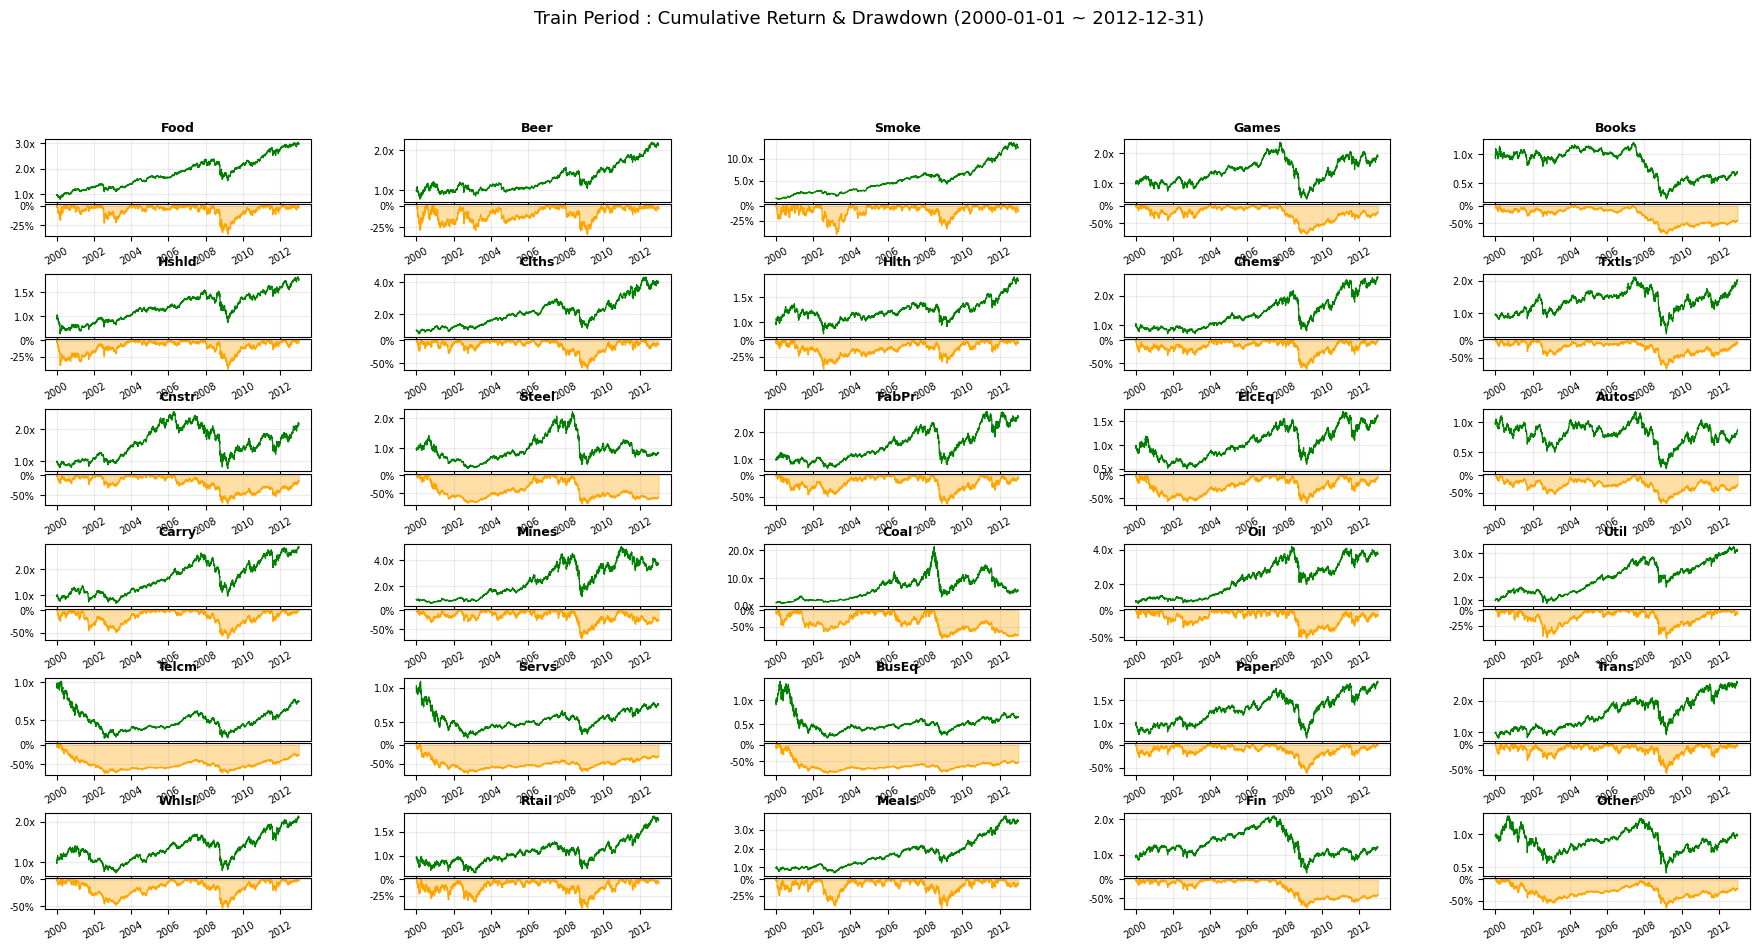

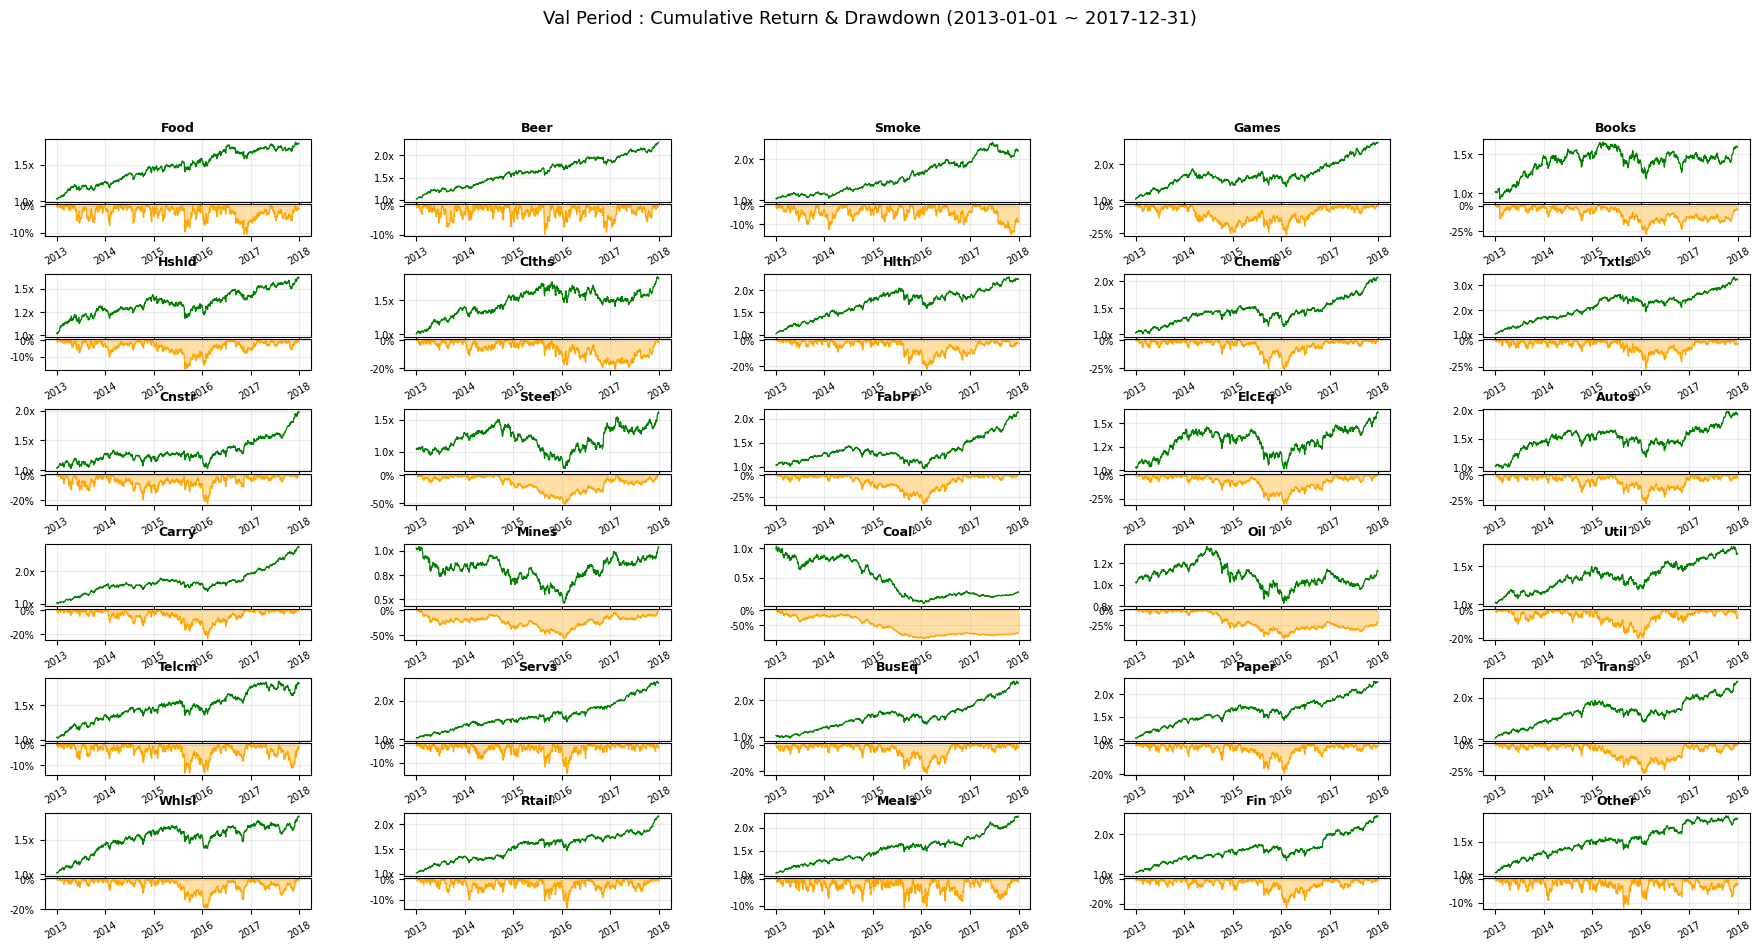

In [39]:
for period_df, period_name, p_start, p_end in [
    (train_df, "Train", TRAIN_START, TRAIN_END),
    (val_df,   "Val",   VAL_START,   VAL_END),
]:
    cum = (1 + period_df).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    cols = cum.columns.tolist()

    fig = plt.figure(figsize=(22, 10))
    outer = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.4, wspace=0.35)

    for i, col in enumerate(cols):
        row, c = divmod(i, 5)
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row, c],
            hspace=0.05, height_ratios=[2, 1]
        )

        ax_ret = fig.add_subplot(inner[0])
        ax_dd  = fig.add_subplot(inner[1], sharex=ax_ret)

        # 상단: 누적 수익률
        ax_ret.plot(cum.index, cum[col], color="green", linewidth=0.9)
        ax_ret.set_title(col, fontsize=9, fontweight="bold")
        ax_ret.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.1f}x"))
        ax_ret.tick_params(axis="x", labelbottom=False)
        ax_ret.tick_params(labelsize=7)
        ax_ret.grid(True, alpha=0.25)

        # 하단: Drawdown
        ax_dd.fill_between(dd.index, dd[col], 0, alpha=0.35, color="orange")
        ax_dd.plot(dd.index, dd[col], color="orange", linewidth=0.8)
        ax_dd.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
        ax_dd.tick_params(labelsize=7)
        ax_dd.tick_params(axis="x", rotation=30)
        ax_dd.grid(True, alpha=0.25)

    fig.suptitle(f"{period_name} Period : Cumulative Return & Drawdown ({p_start} ~ {p_end})",
                 fontsize=13, y=1.01)
    plt.show()


In [40]:
def plot_multi_pnl(results_list, figsize=(14, 8), title="Cumulative PnL Comparison"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                   gridspec_kw={"height_ratios": [3, 1]},
                                   sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    pv_store = []   # summary 계산용

    for (bt_results, label), color in zip(results_list, colors):
        pv = [1.0]
        for res in bt_results:
            w    = res["w_real"]
            base = pv[-1]
            pv.extend((base * (1 + w)).tolist())

        pv          = np.array(pv)
        running_max = np.maximum.accumulate(pv)
        drawdown    = (running_max - pv) / (running_max + 1e-10)
        total_ret   = pv[-1] - 1.0
        max_dd      = drawdown.max()
        calmar      = total_ret / (max_dd + 1e-10)

        full_label = f"{label}  R:{total_ret:.1%}  MDD:{max_dd:.1%}  Cal:{calmar:.2f}"
        ax1.plot(np.arange(len(pv)), pv, color=color, linewidth=1.5, label=full_label)
        ax2.plot(np.arange(len(pv)), -drawdown * 100, color=color, linewidth=1.0, alpha=0.7)
        pv_store.append((label, pv))

    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Portfolio Value")
    ax1.set_title(title)
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.25)

    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Trading Days (BT Period)")
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    # ── Summary Table ──
    print(f"\n{'─'*75}")
    print(f"  {'Label':<35}  {'Ann.Ret':>8}  {'Ann.Vol':>8}  {'MDD':>8}  {'Calmar':>7}")
    print(f"{'─'*75}")
    for label, pv in pv_store:
        daily_rets  = np.diff(pv) / (pv[:-1] + 1e-10)
        n_days      = len(daily_rets)
        ann_ret     = (pv[-1] ** (252 / n_days)) - 1      # 기하 연율화
        ann_vol     = daily_rets.std() * np.sqrt(252)
        running_max = np.maximum.accumulate(pv)
        max_dd      = ((running_max - pv) / (running_max + 1e-10)).max()
        calmar      = ann_ret / (max_dd + 1e-10)
        print(f"  {label:<35}  {ann_ret:>8.2%}  {ann_vol:>8.2%}  {max_dd:>8.2%}  {calmar:>7.2f}")
    print(f"{'─'*75}")


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_mdd_distribution(all_results, title_prefix="DFL-MDD"):
    """
    all_results: list of (results, label) tuples
                 results는 backtest_dfl_mdd의 반환값 (list of dicts with 'M_real')
    """
    n_configs = len(all_results)
    fig = plt.figure(figsize=(16, 5 * n_configs))
    gs = gridspec.GridSpec(n_configs, 3, figure=fig, hspace=0.5, wspace=0.35)

    for row, (results, label) in enumerate(all_results):
        mdds = np.array([r["M_real"] for r in results]) * 100  # % 단위

        windows = np.arange(1, len(mdds) + 1)
        mean_mdd = mdds.mean()
        median_mdd = np.median(mdds)
        p95_mdd = np.percentile(mdds, 95)

        # ── 1. 시계열 바 차트 ──────────────────────────────
        ax1 = fig.add_subplot(gs[row, 0])
        colors = ["#d62728" if v > p95_mdd else "#1f77b4" for v in mdds]
        ax1.bar(windows, mdds, color=colors, alpha=0.8, width=0.7)
        ax1.axhline(mean_mdd,   color="red",    linestyle="--", lw=1.5, label=f"Mean={mean_mdd:.2f}%")
        ax1.axhline(median_mdd, color="orange", linestyle=":",  lw=1.5, label=f"Median={median_mdd:.2f}%")
        ax1.set_xlabel("Rebalancing Window")
        ax1.set_ylabel("MDD (%)")
        ax1.set_title(f"{label}\nPer-Window MDD (time series)")
        ax1.legend(fontsize=8)

        # ── 2. 히스토그램 + KDE ────────────────────────────
        ax2 = fig.add_subplot(gs[row, 1])
        n_bins = min(20, max(5, len(mdds) // 3))
        ax2.hist(mdds, bins=n_bins, color="#1f77b4", alpha=0.7, edgecolor="white",
                 density=True, label="Histogram")

        # KDE
        from scipy.stats import gaussian_kde
        if len(mdds) >= 4:
            kde = gaussian_kde(mdds, bw_method="scott")
            xs  = np.linspace(mdds.min() * 0.8, mdds.max() * 1.1, 300)
            ax2.plot(xs, kde(xs), color="navy", lw=2, label="KDE")

        ax2.axvline(mean_mdd,   color="red",    linestyle="--", lw=1.5, label=f"Mean={mean_mdd:.2f}%")
        ax2.axvline(median_mdd, color="orange", linestyle=":",  lw=1.5, label=f"Median={median_mdd:.2f}%")
        ax2.axvline(p95_mdd,    color="purple", linestyle="-.", lw=1.5, label=f"P95={p95_mdd:.2f}%")
        ax2.set_xlabel("MDD (%)")
        ax2.set_ylabel("Density")
        ax2.set_title(f"{label}\nMDD Distribution")
        ax2.legend(fontsize=8)

        # ── 3. Box + Strip plot ────────────────────────────
        ax3 = fig.add_subplot(gs[row, 2])
        bp = ax3.boxplot(mdds, vert=True, patch_artist=True,
                         boxprops=dict(facecolor="#aec7e8", alpha=0.7),
                         medianprops=dict(color="orange", lw=2),
                         whiskerprops=dict(lw=1.5),
                         flierprops=dict(marker="o", markersize=4,
                                         markerfacecolor="#d62728", alpha=0.7))
        # jitter strip
        jitter = np.random.uniform(-0.1, 0.1, size=len(mdds))
        ax3.scatter(1 + jitter, mdds, alpha=0.5, s=20, color="#1f77b4", zorder=3)

        # 요약 통계 텍스트
        stats_text = (
            f"n={len(mdds)}\n"
            f"Mean  : {mean_mdd:.2f}%\n"
            f"Median: {median_mdd:.2f}%\n"
            f"Std   : {mdds.std():.2f}%\n"
            f"Min   : {mdds.min():.2f}%\n"
            f"Max   : {mdds.max():.2f}%\n"
            f"P95   : {p95_mdd:.2f}%"
        )
        ax3.text(1.35, mdds.max(), stats_text, fontsize=8,
                 va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                           edgecolor="gray", alpha=0.9))
        ax3.set_xticks([])
        ax3.set_ylabel("MDD (%)")
        ax3.set_title(f"{label}\nBoxplot")

    fig.suptitle(f"{title_prefix} — Per-Window MDD Distribution",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

In [32]:
import importlib

import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)

for delta_val in DELTA_LIST:
    for lam_val in LAM_LIST:
        print(f"\n{'='*50}")
        print(f"  delta={delta_val}, lam={lam_val}")
        print(f"{'='*50}")

        all_results_dfl_mdd = []

        for cfg in configs:
            LOOKBACK = cfg["LOOKBACK"]
            n1       = cfg["n1"]

            print(f"\n  ▶ LB={LOOKBACK}, n1={n1} 학습 시작...")

            INPUT_DIM = LOOKBACK * N_STOCKS

            train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=LOOKBACK, end=N_TRAIN)
            val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
            val_samples   = val_samples[::HORIZON]
            rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=BT_START_IDX, end=BT_START_IDX + N_BT)
            rebal_samples = rebal_samples[::REBAL]

            torch.manual_seed(42)

            pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
            opt_layer  = build_optimization_layer(N, M, gamma, delta=delta_val)

            pred_model, train_inaccurate = train_dfl_mdd(
                pred_model, opt_layer, train_samples, val_samples,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam_val,
                is_mean=is_mean, is_std=is_std, delta=delta_val,
                patience=PATIENCE, lr_patience=20, lr_factor=0.5,
            )

            bt_dfl_mdd, bt_inaccurate = backtest_dfl_mdd(
                pred_model=pred_model, opt_layer=opt_layer,
                rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
                n1=n1, x_min=x_min, x_max=x_max,
                delta=delta_val, is_mean=is_mean, is_std=is_std,
                stock_names=stock_names, rebal=REBAL,
            )
            all_results_dfl_mdd.append((bt_dfl_mdd, f"DFL-MDD (LB={LOOKBACK}, n1={n1})"))

        plot_multi_pnl(all_results_dfl_mdd, title=f"DFL-MDD | delta={delta_val}, lam={lam_val}")

        plot_mdd_distribution(
            all_results_dfl_mdd,
            title_prefix=f"DFL-MDD | delta={delta_val}, lam={lam_val}"
        )

DFL-MDD  [1/48]
  delta=20, lam=0.3, LB=252, n1=0.1
  █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  2%


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/cvxpylayers/torch/cvxpylayer.py:429: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:51.)
  torch_csr = torch.sparse_csr_tensor(



── DFL-MDD Training (with Val Early Stopping + LR Scheduler) ──


Exception ignored in: <function tqdm.__del__ at 0x178146700>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


KeyboardInterrupt: 

PTO-MDD:   0%|                 | 0/10 [00:00<?, ?it/s, LB=252, delta=20, n1=0.1]


── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.003949  val=0.001294  *
  Epoch   5/300  train=0.000333  val=0.000202  *
  Epoch  10/300  train=0.000300  val=0.000146  *
  Epoch  15/300  train=0.000300  val=0.000136  *
  Epoch  20/300  train=0.000302  val=0.000134  *
  Epoch  25/300  train=0.000301  val=0.000134  (1/50)
  Epoch  30/300  train=0.000301  val=0.000134  *
  Epoch  35/300  train=0.000301  val=0.000134  (2/50)
  Epoch  40/300  train=0.000300  val=0.000134  (7/50)
  Epoch  45/300  train=0.000302  val=0.000134  (12/50)
  Epoch  50/300  train=0.000301  val=0.000134  (17/50)
  Epoch  55/300  train=0.000301  val=0.000134  (1/50)
  Epoch  60/300  train=0.000300  val=0.000134  (1/50)
  Epoch  65/300  train=0.000301  val=0.000134  (6/50)
  Epoch  70/300  train=0.000300  val=0.000134  (11/50)
  Epoch  75/300  train=0.000300  val=0.000134  (16/50)
  Epoch  80/300  train=0.000301  val=0.000134  (21/50)
  Epoch  85/300  train=0.000301  val=0.000134  (26/50)
 

PTO-MDD:  10%|▉        | 1/10 [00:43<06:29, 43.26s/it, LB=252, delta=20, n1=0.2]

   93    0.0589  56.6585%  {'Smoke': 0.629, 'Mines': 0.215, 'Coal': 0.156}
   94   -0.0538  56.6585%  {'Smoke': 0.616, 'Mines': 0.222, 'Coal': 0.162}
   95    0.0083  56.6585%  {'Smoke': 0.645, 'Mines': 0.213, 'Coal': 0.142}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.003949  val=0.001294  *
  Epoch   5/300  train=0.000333  val=0.000202  *
  Epoch  10/300  train=0.000300  val=0.000146  *
  Epoch  15/300  train=0.000300  val=0.000136  *
  Epoch  20/300  train=0.000302  val=0.000134  *
  Epoch  25/300  train=0.000301  val=0.000134  (1/50)
  Epoch  30/300  train=0.000301  val=0.000134  *
  Epoch  35/300  train=0.000301  val=0.000134  (2/50)
  Epoch  40/300  train=0.000300  val=0.000134  (7/50)
  Epoch  45/300  train=0.000302  val=0.000134  (12/50)
  Epoch  50/300  train=0.000301  val=0.000134  (17/50)
  Epoch  55/300  train=0.000301  val=0.000134  (1/50)
  Epoch  60/300  train=0.000300  val=0.000134  (1/50)
  Epoch  65/300  train=0.000301  val=0.000134  (6/

PTO-MDD:  20%|█▊       | 2/10 [01:20<05:19, 39.90s/it, LB=252, delta=20, n1=0.3]

...

   92    0.0147  71.5959%  {'Mines': 0.367, 'Coal': 0.36, 'Smoke': 0.273}
   93    0.1530  71.5959%  {'Mines': 0.376, 'Coal': 0.345, 'Smoke': 0.278}
   94   -0.0464  71.5959%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5959%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004491  val=0.001564  *
  Epoch   5/300  train=0.000341  val=0.000228  *
  Epoch  10/300  train=0.000298  val=0.000159  *
  Epoch  15/300  train=0.000297  val=0.000139  *
  Epoch  20/300  train=0.000298  val=0.000134  *
  Epoch  25/300  train=0.000299  val=0.000134  *
  Epoch  30/300  train=0.000299  val=0.000134  (2/50)
  Epoch  35/300  train=0.000299  val=0.000134  (7/50)
  Epoch  40/300  train=0.000299  val=0.000134  *
  Epoch  45/300  train=0.000299  val=0.000134  (5/50)
  Epoch  50/300  train=0.000299  val=0.000134  (10/50)
  Epoch  55/300  train=0.000299  val=0.000134  (15/50)
  Epoch  60/300  train=0.000299  va

PTO-MDD:  90%|████████ | 9/10 [07:57<01:02, 62.36s/it, LB=504, delta=20, n1=0.5]

   93    0.1530  71.5962%  {'Mines': 0.376, 'Coal': 0.345, 'Smoke': 0.278}
   94   -0.0464  71.5962%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5962%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004491  val=0.001564  *
  Epoch   5/300  train=0.000341  val=0.000228  *
  Epoch  10/300  train=0.000298  val=0.000159  *
  Epoch  15/300  train=0.000297  val=0.000139  *
  Epoch  20/300  train=0.000298  val=0.000134  *
  Epoch  25/300  train=0.000299  val=0.000134  *
  Epoch  30/300  train=0.000299  val=0.000134  (2/50)
  Epoch  35/300  train=0.000299  val=0.000134  (7/50)
  Epoch  40/300  train=0.000299  val=0.000134  *
  Epoch  45/300  train=0.000299  val=0.000134  (5/50)
  Epoch  50/300  train=0.000299  val=0.000134  (10/50)
  Epoch  55/300  train=0.000299  val=0.000134  (15/50)
  Epoch  60/300  train=0.000299  val=0.000134  (20/50)
  Epoch  65/300  train=0.000299  val=0.000134  (25/50)

PTO-MDD: 100%|████████| 10/10 [09:07<00:00, 64.94s/it, LB=504, delta=20, n1=0.5]

   94   -0.0464  71.5959%  {'Mines': 0.371, 'Coal': 0.344, 'Smoke': 0.285}
   95    0.0117  71.5959%  {'Mines': 0.373, 'Coal': 0.322, 'Smoke': 0.305}


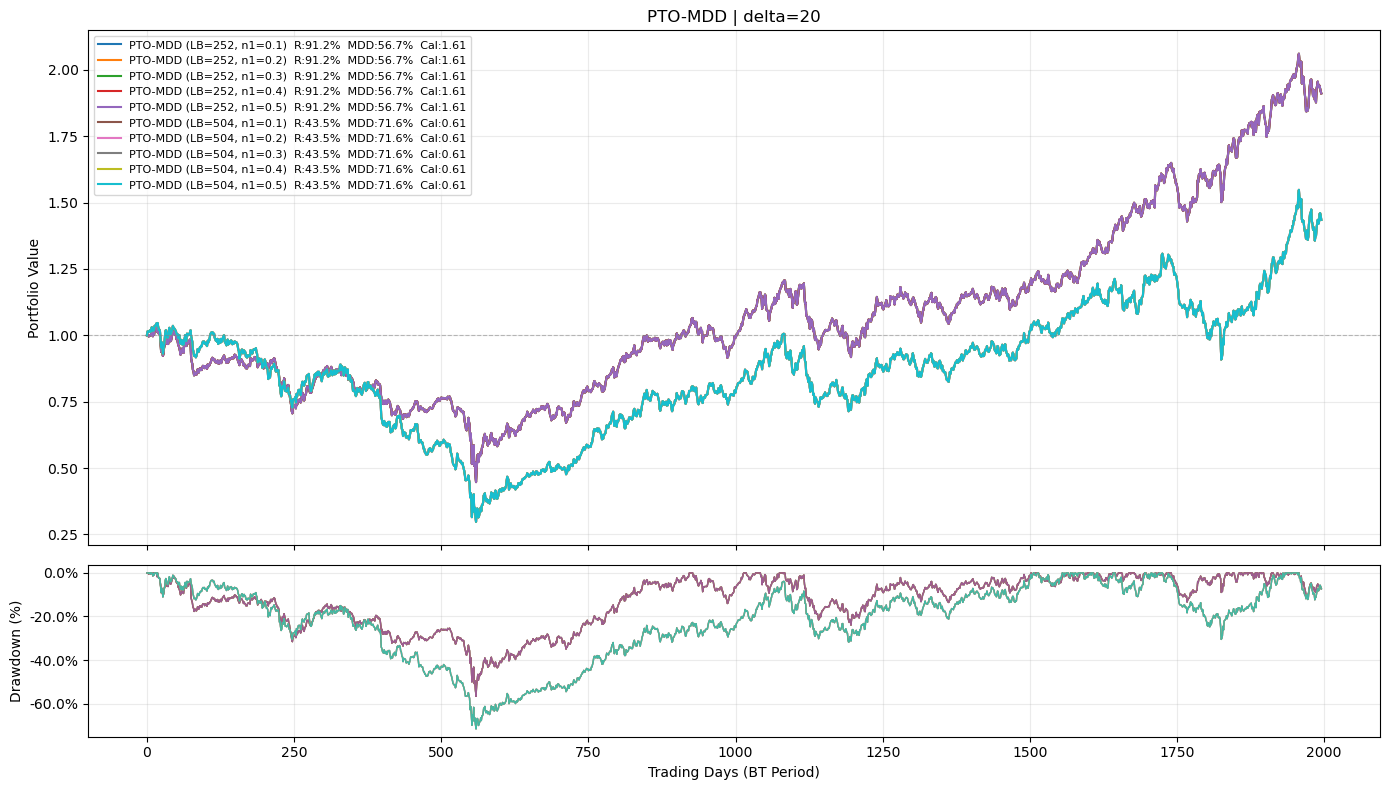

PTO-MDD: 100%|████████| 10/10 [09:08<00:00, 54.81s/it, LB=504, delta=20, n1=0.5]


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MDD (LB=252, n1=0.1)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.2)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.3)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.4)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=252, n1=0.5)                8.53%    22.02%    56.66%     0.15
  PTO-MDD (LB=504, n1=0.1)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.2)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.3)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.4)                4.67%    28.18%    71.60%     0.07
  PTO-MDD (LB=504, n1=0.5)                4.67%    28.18%    71.60%     0.07


In [35]:
import importlib

import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd import train_pto_mdd, backtest_pto_mdd

for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    all_results_pto_mdd = []

    for cfg in configs:
        LOOKBACK = cfg["LOOKBACK"]
        n1       = cfg["n1"]

        print(f"\n  ▶ LB={LOOKBACK}, n1={n1} 학습 시작...")

        INPUT_DIM = LOOKBACK * N_STOCKS

        train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=LOOKBACK, end=N_TRAIN)
        val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        val_samples   = val_samples[::HORIZON]

        rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::REBAL]

        torch.manual_seed(42)

        model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mdd = backtest_pto_mdd(
            model_pto_mdd, rebal_samples, N, d, C,
            n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
            delta=delta_val,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names, rebal=REBAL,
        )
        all_results_pto_mdd.append((bt_pto_mdd, f"PTO-MDD (LB={LOOKBACK}, n1={n1})"))

    plot_multi_pnl(all_results_pto_mdd, title=f"PTO-MDD | delta={delta_val}")

    plot_mdd_distribution(
        all_results_pto_mdd,
        title_prefix=f"PTO-MDD | delta={delta_val}"
    )


  delta=20

  ▶ LB=252 학습 시작...

── PTO-MVO Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004275  val=0.001694  *
  Epoch   5/300  train=0.000343  val=0.000181  *
  Epoch  10/300  train=0.000304  val=0.000143  *
  Epoch  15/300  train=0.000302  val=0.000141  *
  Epoch  20/300  train=0.000302  val=0.000141  (5/50)
  Epoch  25/300  train=0.000302  val=0.000141  (10/50)
  Epoch  30/300  train=0.000302  val=0.000141  (15/50)
  Epoch  35/300  train=0.000302  val=0.000141  (20/50)
  Epoch  40/300  train=0.000302  val=0.000141  (25/50)
  Epoch  45/300  train=0.000302  val=0.000141  (30/50)
  Epoch  50/300  train=0.000302  val=0.000141  (35/50)
  Epoch  55/300  train=0.000302  val=0.000141  (40/50)
  Epoch  60/300  train=0.000302  val=0.000141  (45/50)
  Epoch  65/300  train=0.000302  val=0.000141  (50/50)
  Early stopping at epoch 65  (best val=0.000141)

── Backtest : PTO-MVO ──
 Win    R_real    MDD(%)  Top-3 weights
-------------------------------------------------------

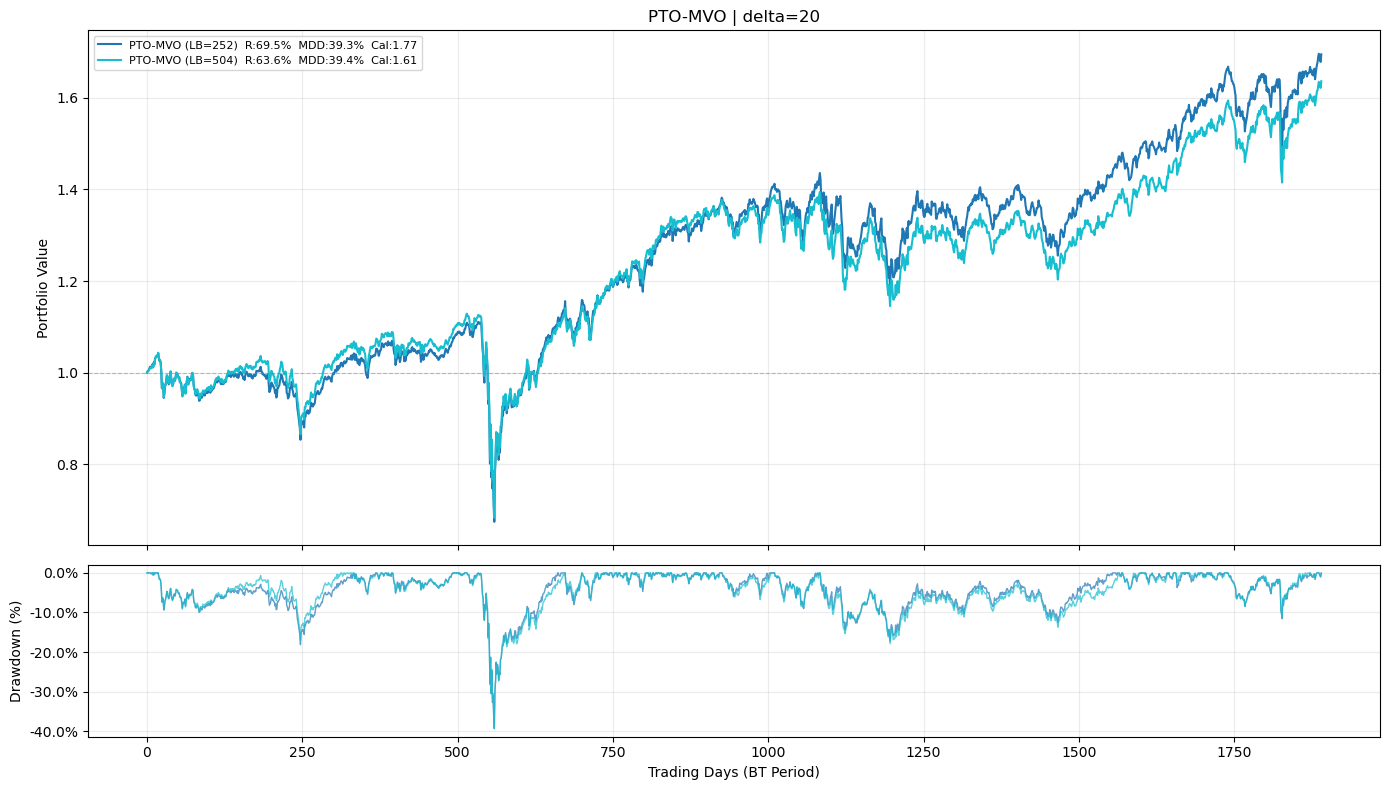


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MVO (LB=252)                        7.29%    18.09%    39.25%     0.19
  PTO-MVO (LB=504)                        6.78%    18.23%    39.41%     0.17
───────────────────────────────────────────────────────────────────────────


/var/folders/j4/2041ftmn23q6ckn4xskb5z9c0000gn/T/ipykernel_99413/2786756890.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


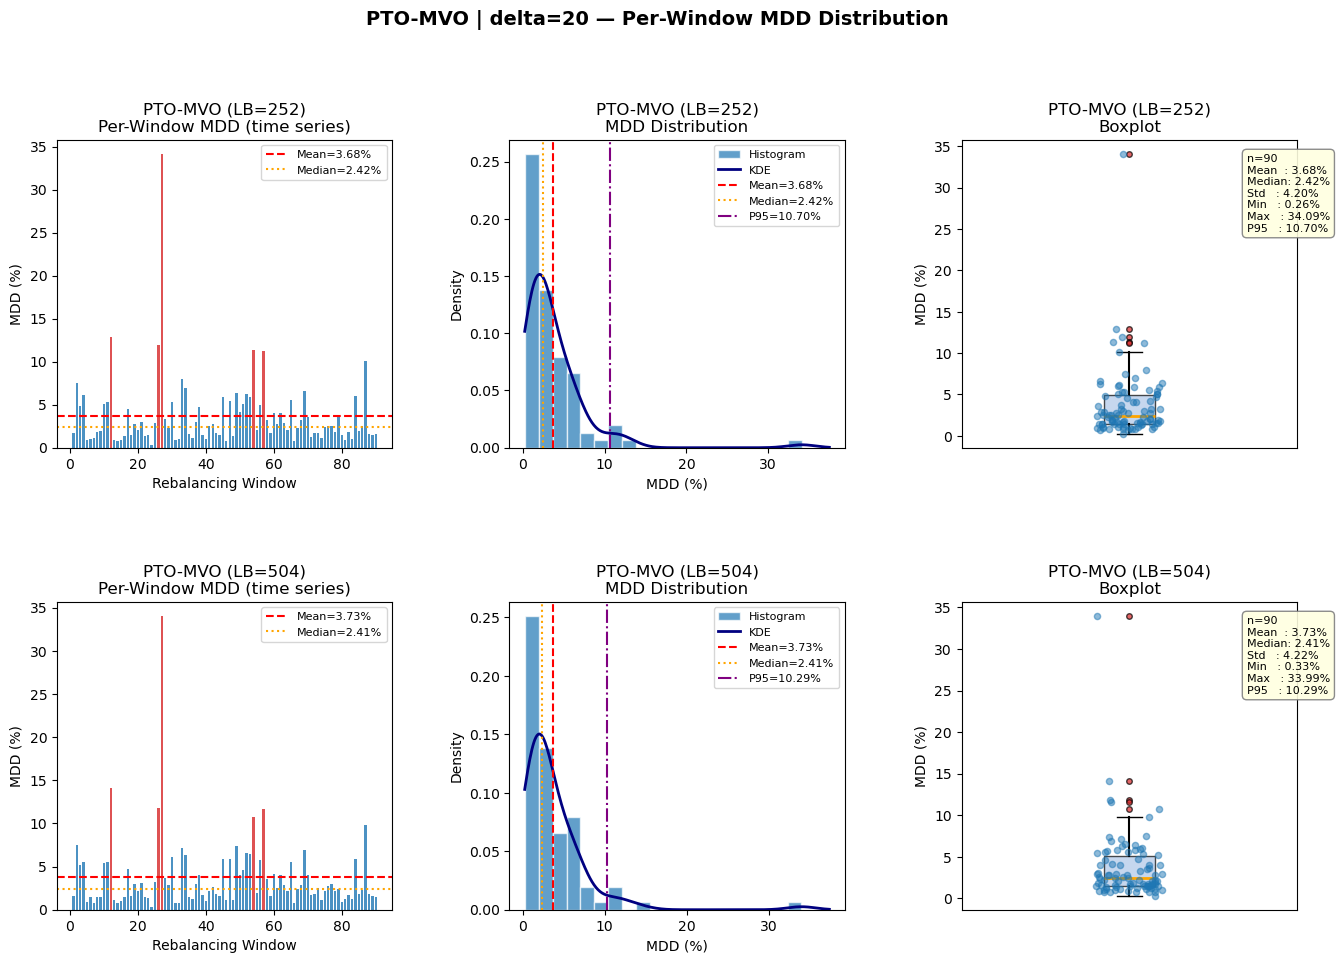


  delta=50

  ▶ LB=252 학습 시작...

── PTO-MVO Training (MSE + Val Early Stopping) ──
  Epoch   1/300  train=0.004275  val=0.001694  *
  Epoch   5/300  train=0.000343  val=0.000181  *
  Epoch  10/300  train=0.000304  val=0.000143  *
  Epoch  15/300  train=0.000302  val=0.000141  *
  Epoch  20/300  train=0.000302  val=0.000141  (5/50)
  Epoch  25/300  train=0.000302  val=0.000141  (10/50)
  Epoch  30/300  train=0.000302  val=0.000141  (15/50)
  Epoch  35/300  train=0.000302  val=0.000141  (20/50)
  Epoch  40/300  train=0.000302  val=0.000141  (25/50)
  Epoch  45/300  train=0.000302  val=0.000141  (30/50)
  Epoch  50/300  train=0.000302  val=0.000141  (35/50)
  Epoch  55/300  train=0.000302  val=0.000141  (40/50)
  Epoch  60/300  train=0.000302  val=0.000141  (45/50)
  Epoch  65/300  train=0.000302  val=0.000141  (50/50)
  Early stopping at epoch 65  (best val=0.000141)

── Backtest : PTO-MVO ──
 Win    R_real    MDD(%)  Top-3 weights
-------------------------------------------------------

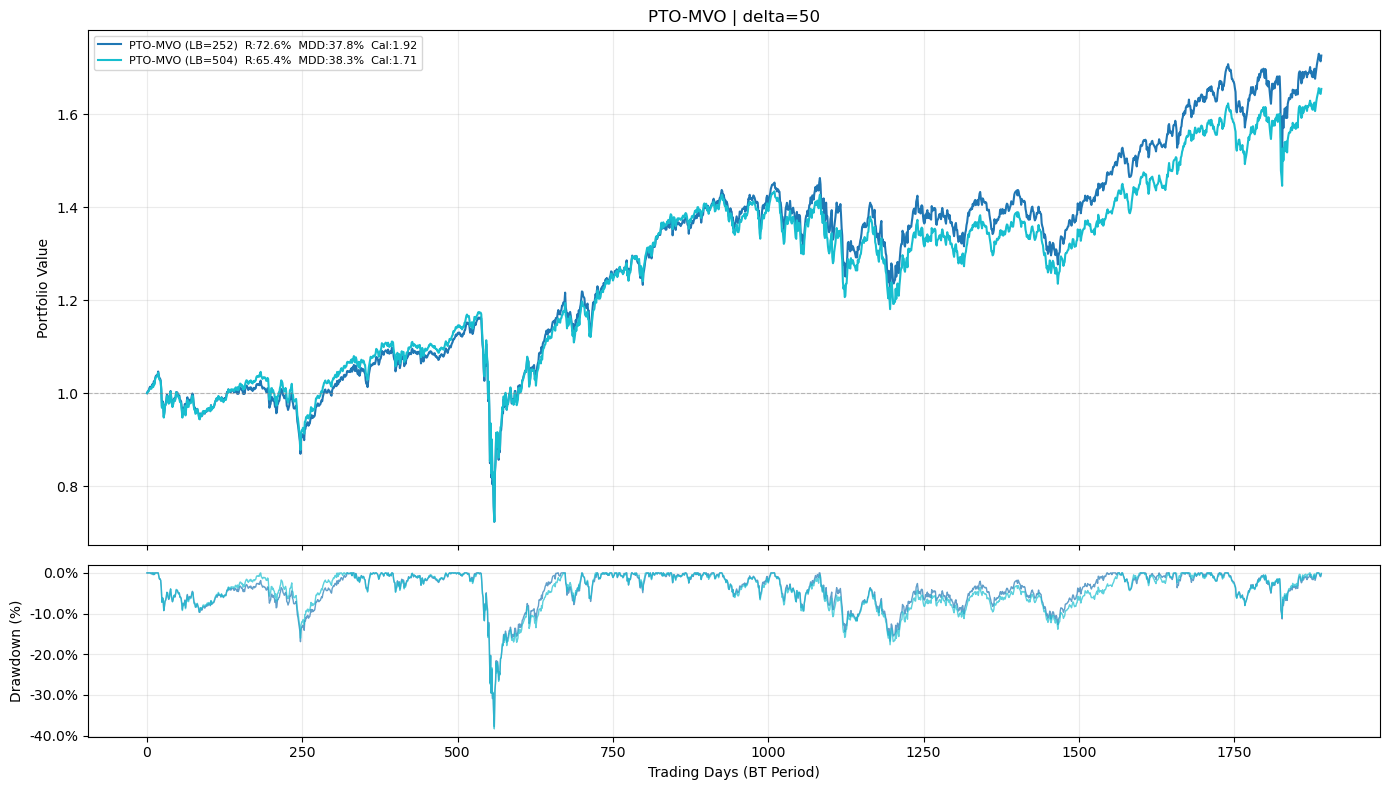


───────────────────────────────────────────────────────────────────────────
  Label                                 Ann.Ret   Ann.Vol       MDD   Calmar
───────────────────────────────────────────────────────────────────────────
  PTO-MVO (LB=252)                        7.55%    17.69%    37.79%     0.20
  PTO-MVO (LB=504)                        6.94%    17.95%    38.35%     0.18
───────────────────────────────────────────────────────────────────────────


/var/folders/j4/2041ftmn23q6ckn4xskb5z9c0000gn/T/ipykernel_99413/2786756890.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


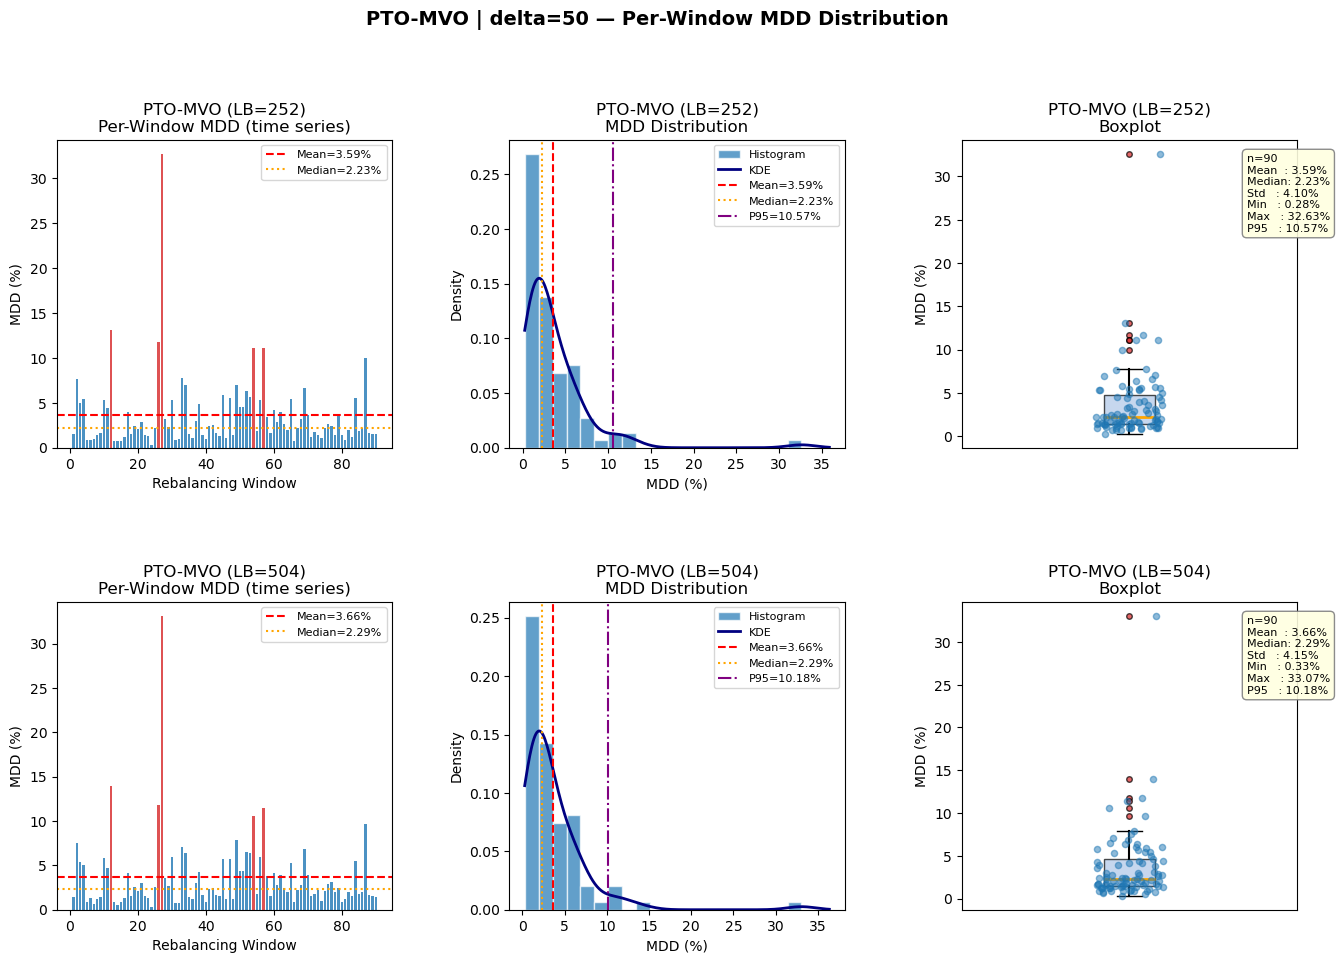

In [44]:
import importlib

import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo import train_pto_mvo, backtest_pto_mvo

for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    all_results_mvo = []

    for lookback in LOOKBACK_LIST:
        print(f"\n  ▶ LB={lookback} 학습 시작...")

        INPUT_DIM = lookback * N_STOCKS

        train_samples = make_windows(full_np, lookback, HORIZON,
                                     start=lookback, end=N_TRAIN)
        val_samples   = make_windows(full_np, lookback, HORIZON,
                                     start=VAL_START_IDX, end=VAL_START_IDX + N_VAL)
        val_samples   = val_samples[::HORIZON]

        rebal_samples = make_windows(full_np, lookback, HORIZON,
                                     start=BT_START_IDX, end=BT_START_IDX + N_BT)
        rebal_samples = rebal_samples[::REBAL]

        torch.manual_seed(42)

        model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
        train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                      EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

        bt_pto_mvo = backtest_pto_mvo(
            model_pto_mvo, rebal_samples, N, d, C,
            delta=delta_val,
            x_min=x_min, x_max=x_max, gamma=gamma,
            is_mean=is_mean, is_std=is_std,
            stock_names=stock_names,
            rebal=REBAL,
        )
        all_results_mvo.append((bt_pto_mvo, f"PTO-MVO (LB={lookback})"))

    plot_multi_pnl(all_results_mvo, title=f"PTO-MVO | delta={delta_val}")

    plot_mdd_distribution(
        all_results_mvo,                          # ← 오타 수정
        title_prefix=f"PTO-MVO | delta={delta_val}"
    )